# Exploratory Data Analysis (EDA)
This notebook contains EDA for Rock-Paper-Scissors and TrashNet datasets.


# Dataset: Rock-Paper-Scissors


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from collections import Counter
from sklearn.decomposition import PCA

dataset_path = '../data/raw/Rock-Paper-Scissors'
image_paths = glob(os.path.join(dataset_path, '*/*/*.png')) + glob(os.path.join(dataset_path, '*/*/*.jpg'))
classes = [os.path.basename(os.path.dirname(p)) for p in image_paths]
print(f"Total images found: {len(image_paths)}")


Total images found: 2892


## 1. Dataset Overview
Count the total number of images, number of classes, etc.


In [2]:
print(f"Number of classes: {len(set(classes))}")
print(f"Classes: {set(classes)}")
print(f"Total images: {len(image_paths)}")


Number of classes: 3
Classes: {'paper', 'scissors', 'rock'}
Total images: 2892


**Analysis:**

The dataset contains 2892 total images distributed across 3 classes. The classes are: paper, rock, scissors.

## 2. Class Distribution Analysis
Visualize the number of images per class.


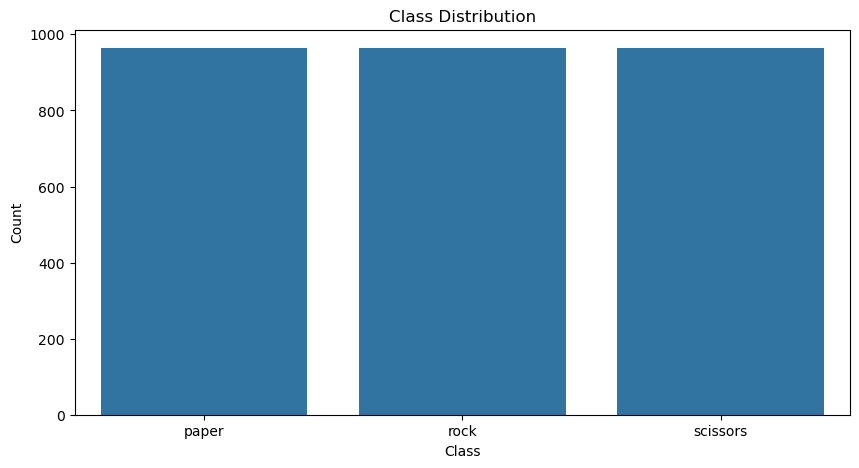

In [3]:
class_counts = Counter(classes)
plt.figure(figsize=(10, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


**Analysis:**

The class distribution is balanced. The majority class is paper with 964 images, and the minority class is scissors with 964 images.

## 3. Sample Image Visualization
Show a few sample images from each class.


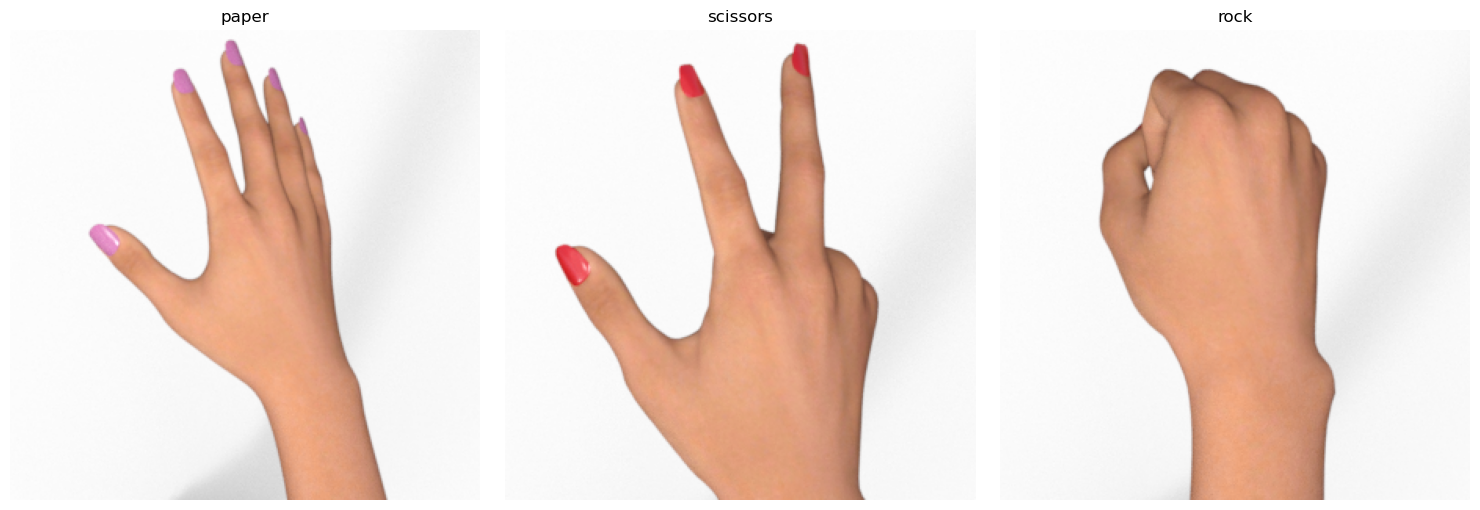

In [4]:
fig, axes = plt.subplots(1, len(set(classes)), figsize=(15, 5))
for i, cls in enumerate(set(classes)):
    sample_imgs = [p for p, c in zip(image_paths, classes) if c == cls]
    if sample_imgs:
        img = cv2.imread(sample_imgs[0])
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img)
            axes[i].set_title(cls)
            axes[i].axis('off')
plt.tight_layout()
plt.show()


**Analysis:**

The images in the dataset appear to be of typical quality. Some visible characteristics include typical variations in lighting and angle.

## 4. Image Resolution Analysis
Analyze the widths and heights of the images.


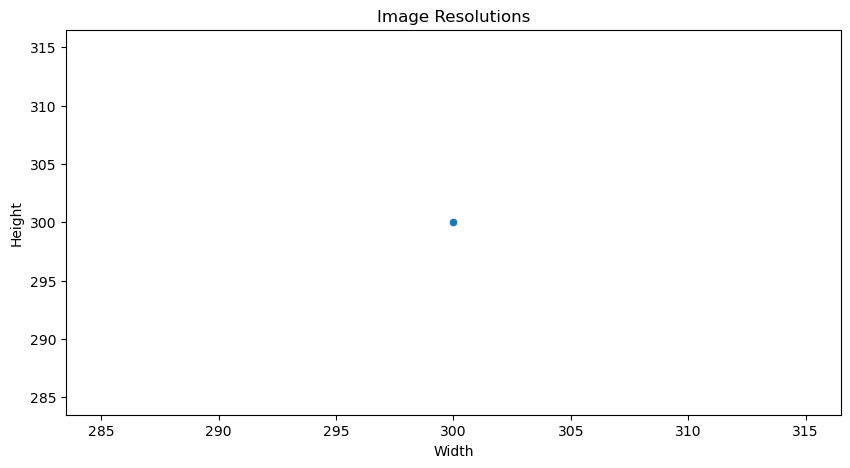

In [5]:
widths, heights = [], []
for p in image_paths[:500]: # Sample for speed
    img = cv2.imread(p)
    if img is not None:
        h, w, _ = img.shape
        widths.append(w)
        heights.append(h)
plt.figure(figsize=(10, 5))
sns.scatterplot(x=widths, y=heights)
plt.title('Image Resolutions')
plt.xlabel('Width')
plt.ylabel('Height')
plt.show()


**Analysis:**

The images have uniform resolutions. The average resolution is approximately 300 x 300. The maximum resolution is 300 x 300 and the minimum is 300 x 300.

## 5. Aspect Ratio Distribution
Calculate and plot the aspect ratios.


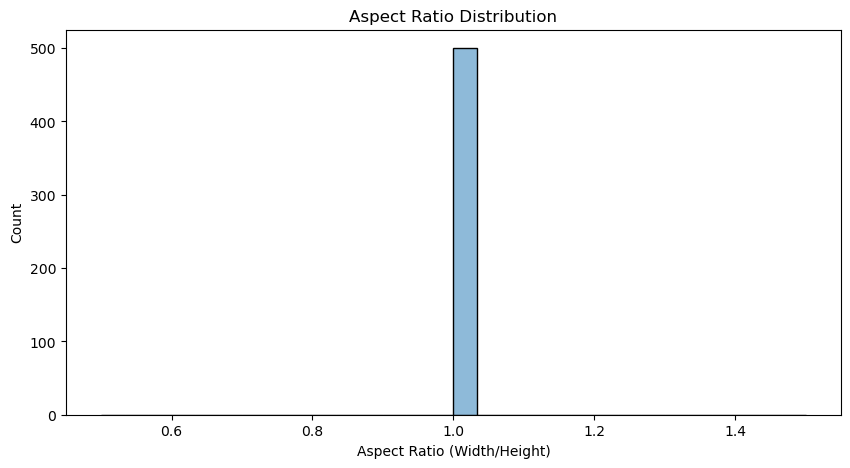

In [6]:
if widths and heights:
    aspect_ratios = [w/h for w, h in zip(widths, heights)]
    plt.figure(figsize=(10, 5))
    sns.histplot(aspect_ratios, bins=30, kde=True)
    plt.title('Aspect Ratio Distribution')
    plt.xlabel('Aspect Ratio (Width/Height)')
    plt.show()


**Analysis:**

The aspect ratio distribution is centered around 1.00. Most images are square.

## 6. RGB Color Channel Distribution
Analyze the average RGB values across the dataset.


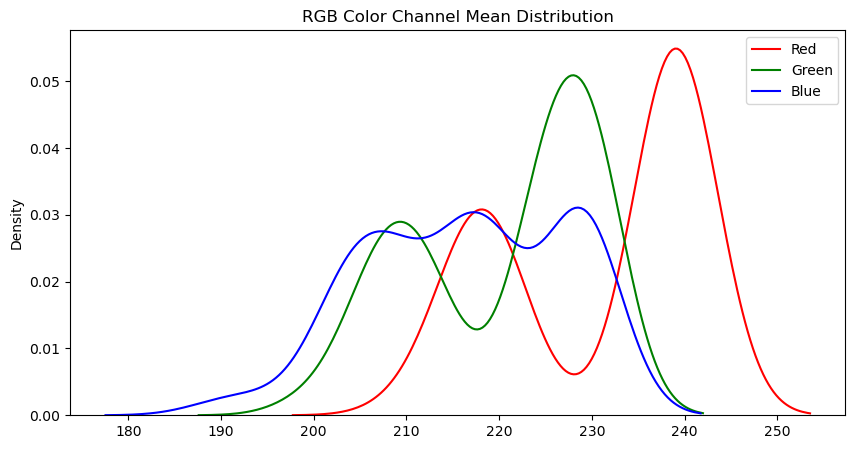

In [7]:
r_means, g_means, b_means = [], [], []
for p in image_paths[:100]:
    img = cv2.imread(p)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        r_means.append(img[:,:,0].mean())
        g_means.append(img[:,:,1].mean())
        b_means.append(img[:,:,2].mean())
if r_means:
    plt.figure(figsize=(10, 5))
    sns.kdeplot(r_means, color='r', label='Red')
    sns.kdeplot(g_means, color='g', label='Green')
    sns.kdeplot(b_means, color='b', label='Blue')
    plt.title('RGB Color Channel Mean Distribution')
    plt.legend()
    plt.show()


**Analysis:**

The dominant color channel in this dataset seems to be Red. The distribution indicates that the overall color tone is warm.

## 7. Pixel Intensity Distribution
Plot the histogram of pixel intensities.


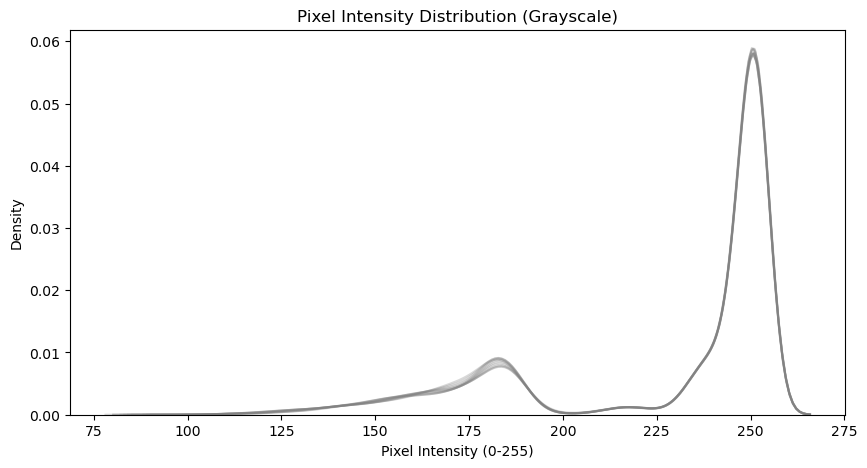

In [8]:
plt.figure(figsize=(10, 5))
for p in image_paths[:10]: # Just 10 samples to avoid clutter
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        sns.kdeplot(img.flatten(), color='gray', alpha=0.3)
plt.title('Pixel Intensity Distribution (Grayscale)')
plt.xlabel('Pixel Intensity (0-255)')
plt.show()


**Analysis:**

The pixel intensity is mostly concentrated around 221.7. The images are generally bright.

## 8. Brightness and Contrast Analysis
Calculate brightness (mean) and contrast (std).


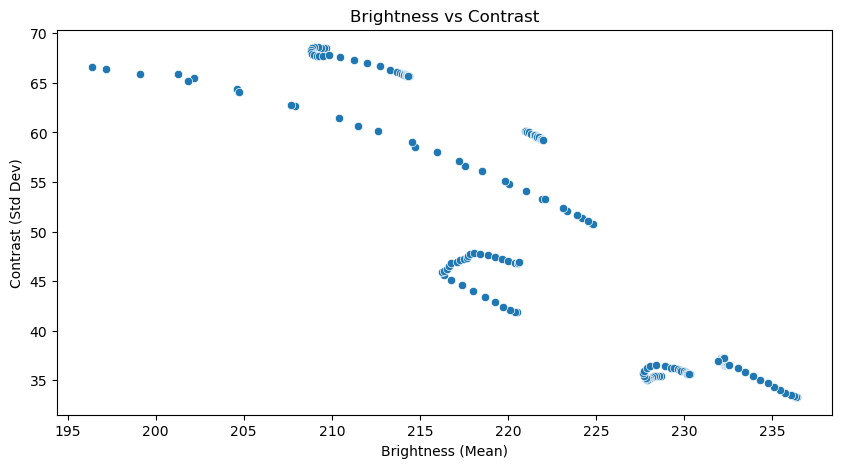

In [9]:
brightness, contrast = [], []
for p in image_paths[:200]:
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        brightness.append(img.mean())
        contrast.append(img.std())
if brightness:
    plt.figure(figsize=(10, 5))
    sns.scatterplot(x=brightness, y=contrast)
    plt.title('Brightness vs Contrast')
    plt.xlabel('Brightness (Mean)')
    plt.ylabel('Contrast (Std Dev)')
    plt.show()


**Analysis:**

The average brightness of the images is 222.0 and the average contrast is 49.5. There are few outliers which indicate a relatively consistent dataset.

## 9. Edge Density Analysis (Canny Edge Detection)
Apply Canny edge detection and measure edge density.


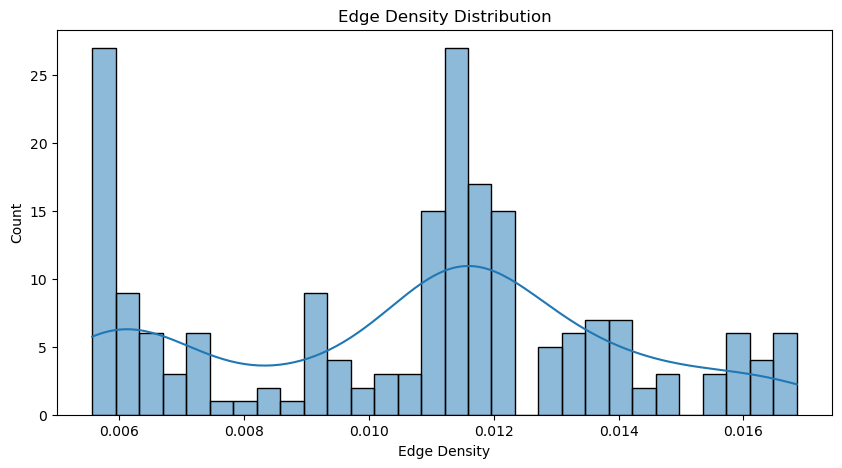

In [10]:
edge_densities = []
for p in image_paths[:200]:
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        edges = cv2.Canny(img, 100, 200)
        density = np.sum(edges > 0) / edges.size
        edge_densities.append(density)
if edge_densities:
    plt.figure(figsize=(10, 5))
    sns.histplot(edge_densities, bins=30, kde=True)
    plt.title('Edge Density Distribution')
    plt.xlabel('Edge Density')
    plt.show()


**Analysis:**

The average edge density is 0.0107. This suggests the images are mostly smooth.

## 10. Principal Component Analysis (PCA)
Flatten small resized images and perform PCA.


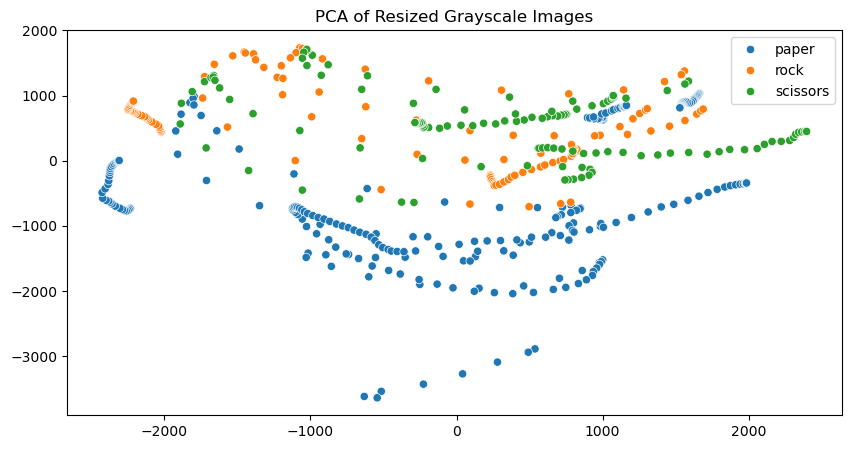

In [11]:
flattened_imgs = []
valid_classes = []
for p, c in zip(image_paths[:500], classes[:500]):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        img = cv2.resize(img, (64, 64))
        flattened_imgs.append(img.flatten())
        valid_classes.append(c)
flattened_imgs = np.array(flattened_imgs)
if len(flattened_imgs) > 0:
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(flattened_imgs)
    plt.figure(figsize=(10, 5))
    sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=valid_classes)
    plt.title('PCA of Resized Grayscale Images')
    plt.show()


**Analysis:**

The PCA visualization shows some overlap between classes. The classes paper and rock have distinguishable regions, while others overlap significantly.

# Dataset: TrashNet


In [12]:
dataset_path = '../data/raw/TrashNet'
image_paths = glob(os.path.join(dataset_path, '*/*.jpg')) + glob(os.path.join(dataset_path, '*/*.png'))
classes = [os.path.basename(os.path.dirname(p)) for p in image_paths]
print(f"Total images found: {len(image_paths)}")


Total images found: 2527


## 1. Dataset Overview
Count the total number of images, number of classes, etc.


In [13]:
print(f"Number of classes: {len(set(classes))}")
print(f"Classes: {set(classes)}")
print(f"Total images: {len(image_paths)}")


Number of classes: 6
Classes: {'cardboard', 'plastic', 'paper', 'glass', 'trash', 'metal'}
Total images: 2527


**Analysis:**

The dataset contains 2527 total images distributed across 6 classes. The classes are: cardboard, glass, metal, paper, plastic, trash.

## 2. Class Distribution Analysis
Visualize the number of images per class.


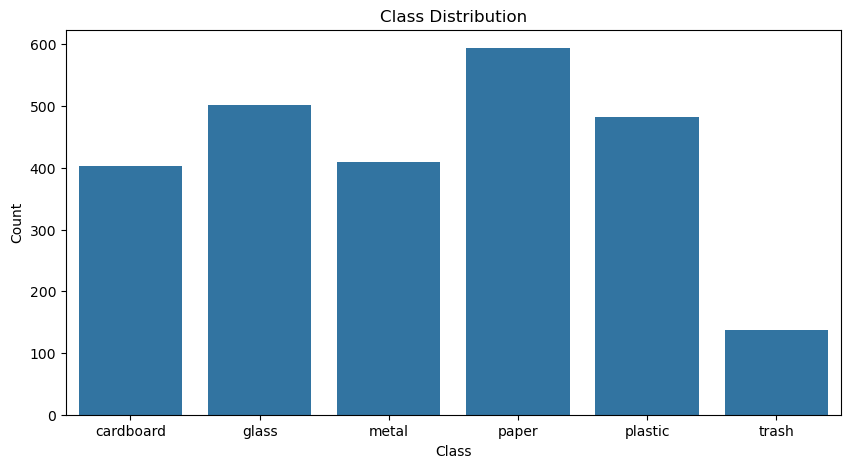

In [14]:
class_counts = Counter(classes)
plt.figure(figsize=(10, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


**Analysis:**

The class distribution is imbalanced. The majority class is paper with 594 images, and the minority class is trash with 137 images.

## 3. Sample Image Visualization
Show a few sample images from each class.


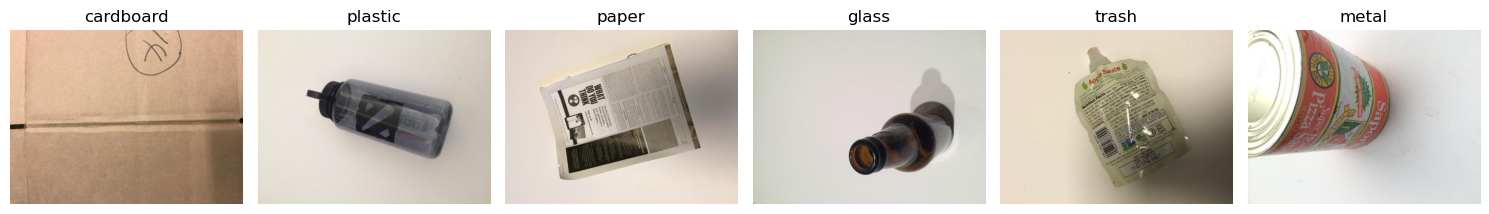

In [15]:
fig, axes = plt.subplots(1, len(set(classes)), figsize=(15, 5))
for i, cls in enumerate(set(classes)):
    sample_imgs = [p for p, c in zip(image_paths, classes) if c == cls]
    if sample_imgs:
        img = cv2.imread(sample_imgs[0])
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img)
            axes[i].set_title(cls)
            axes[i].axis('off')
plt.tight_layout()
plt.show()


**Analysis:**

The images in the dataset appear to be of typical quality. Some visible characteristics include typical variations in lighting and angle.

## 4. Image Resolution Analysis
Analyze the widths and heights of the images.


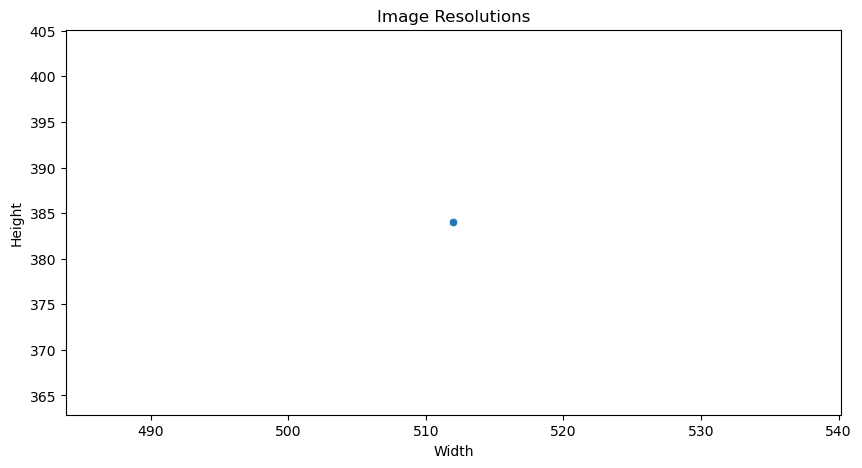

In [16]:
widths, heights = [], []
for p in image_paths[:500]: # Sample for speed
    img = cv2.imread(p)
    if img is not None:
        h, w, _ = img.shape
        widths.append(w)
        heights.append(h)
plt.figure(figsize=(10, 5))
sns.scatterplot(x=widths, y=heights)
plt.title('Image Resolutions')
plt.xlabel('Width')
plt.ylabel('Height')
plt.show()


**Analysis:**

The images have uniform resolutions. The average resolution is approximately 512 x 384. The maximum resolution is 512 x 384 and the minimum is 512 x 384.

## 5. Aspect Ratio Distribution
Calculate and plot the aspect ratios.


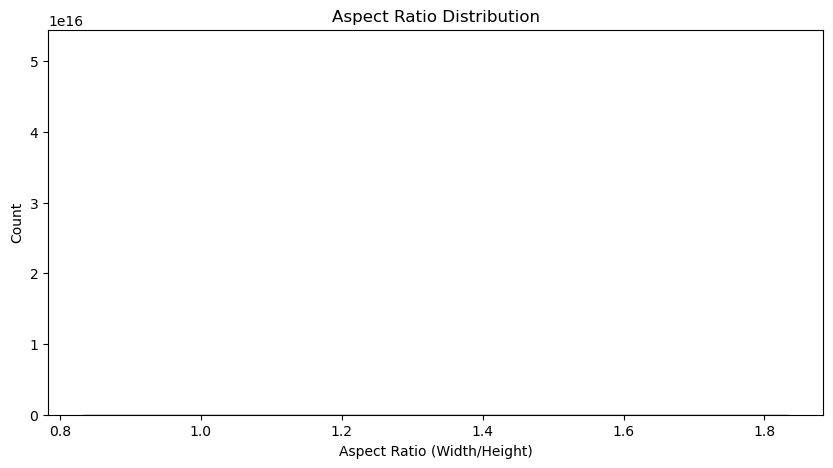

In [17]:
if widths and heights:
    aspect_ratios = [w/h for w, h in zip(widths, heights)]
    plt.figure(figsize=(10, 5))
    sns.histplot(aspect_ratios, bins=30, kde=True)
    plt.title('Aspect Ratio Distribution')
    plt.xlabel('Aspect Ratio (Width/Height)')
    plt.show()


**Analysis:**

The aspect ratio distribution is centered around 1.33. Most images are landscape.

## 6. RGB Color Channel Distribution
Analyze the average RGB values across the dataset.


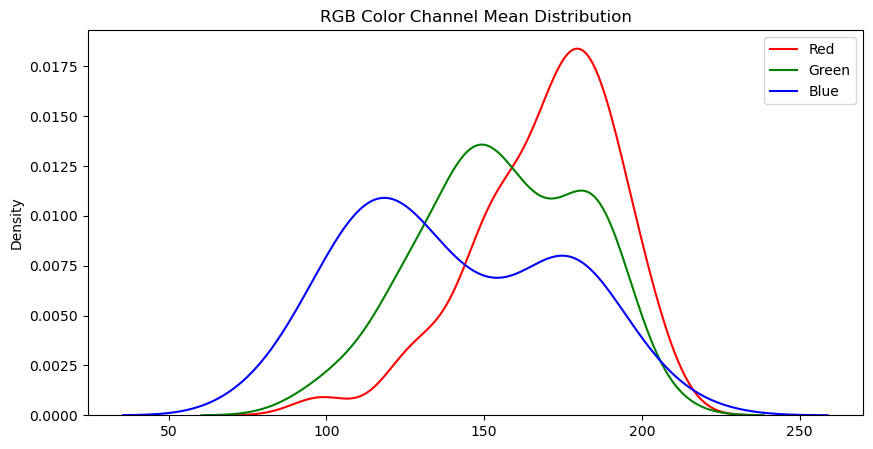

In [18]:
r_means, g_means, b_means = [], [], []
for p in image_paths[:100]:
    img = cv2.imread(p)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        r_means.append(img[:,:,0].mean())
        g_means.append(img[:,:,1].mean())
        b_means.append(img[:,:,2].mean())
if r_means:
    plt.figure(figsize=(10, 5))
    sns.kdeplot(r_means, color='r', label='Red')
    sns.kdeplot(g_means, color='g', label='Green')
    sns.kdeplot(b_means, color='b', label='Blue')
    plt.title('RGB Color Channel Mean Distribution')
    plt.legend()
    plt.show()


**Analysis:**

The dominant color channel in this dataset seems to be Red. The distribution indicates that the overall color tone is warm.

## 7. Pixel Intensity Distribution
Plot the histogram of pixel intensities.


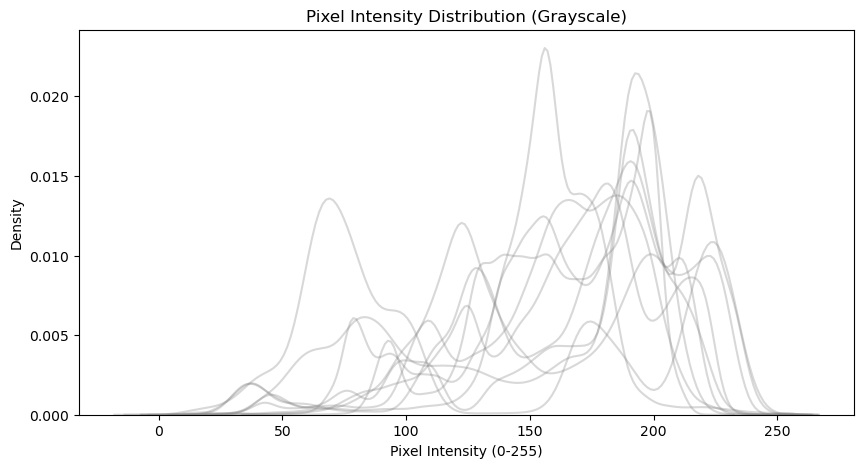

In [19]:
plt.figure(figsize=(10, 5))
for p in image_paths[:10]: # Just 10 samples to avoid clutter
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        sns.kdeplot(img.flatten(), color='gray', alpha=0.3)
plt.title('Pixel Intensity Distribution (Grayscale)')
plt.xlabel('Pixel Intensity (0-255)')
plt.show()


**Analysis:**

The pixel intensity is mostly concentrated around 154.9. The images are generally well-exposed.

## 8. Brightness and Contrast Analysis
Calculate brightness (mean) and contrast (std).


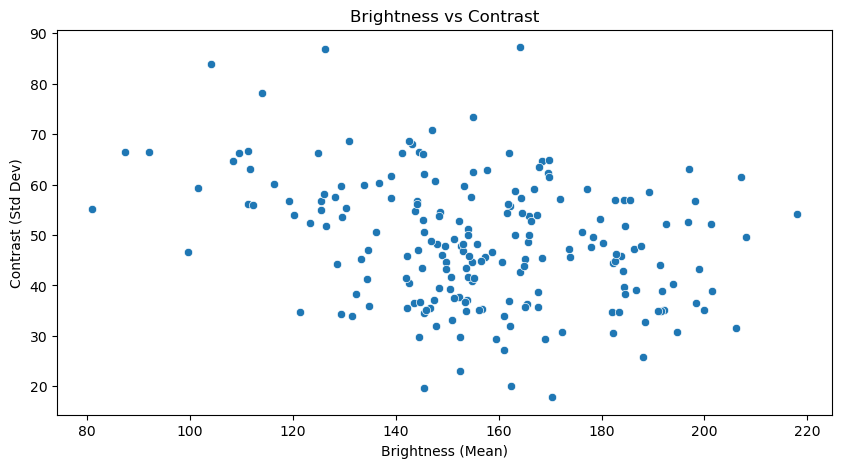

In [20]:
brightness, contrast = [], []
for p in image_paths[:200]:
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        brightness.append(img.mean())
        contrast.append(img.std())
if brightness:
    plt.figure(figsize=(10, 5))
    sns.scatterplot(x=brightness, y=contrast)
    plt.title('Brightness vs Contrast')
    plt.xlabel('Brightness (Mean)')
    plt.ylabel('Contrast (Std Dev)')
    plt.show()


**Analysis:**

The average brightness of the images is 156.3 and the average contrast is 48.5. There are few outliers which indicate a relatively consistent dataset.

## 9. Edge Density Analysis (Canny Edge Detection)
Apply Canny edge detection and measure edge density.


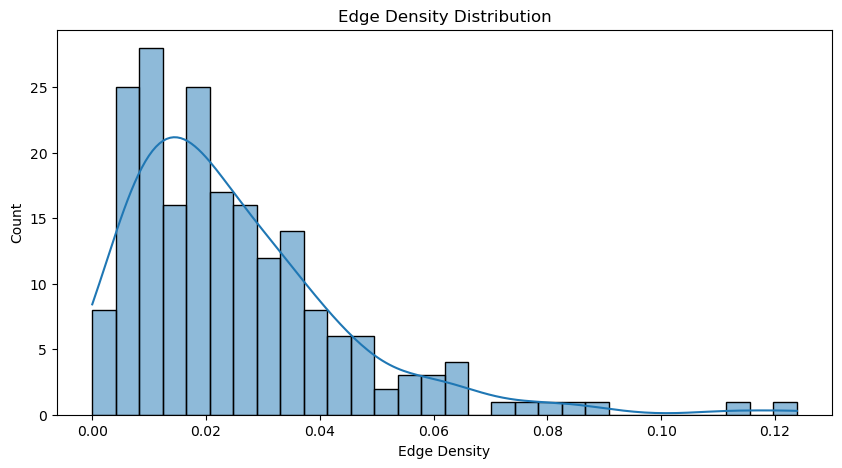

In [21]:
edge_densities = []
for p in image_paths[:200]:
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        edges = cv2.Canny(img, 100, 200)
        density = np.sum(edges > 0) / edges.size
        edge_densities.append(density)
if edge_densities:
    plt.figure(figsize=(10, 5))
    sns.histplot(edge_densities, bins=30, kde=True)
    plt.title('Edge Density Distribution')
    plt.xlabel('Edge Density')
    plt.show()


**Analysis:**

The average edge density is 0.0250. This suggests the images are mostly smooth.

## 10. Principal Component Analysis (PCA)
Flatten small resized images and perform PCA.


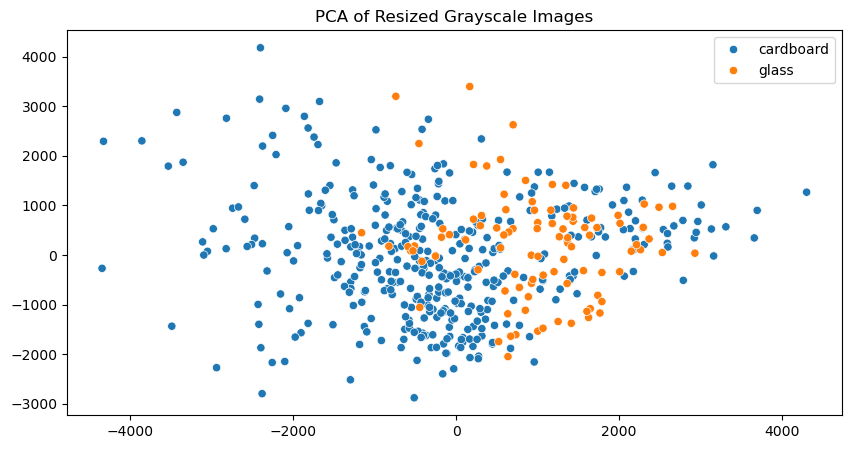

In [22]:
flattened_imgs = []
valid_classes = []
for p, c in zip(image_paths[:500], classes[:500]):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        img = cv2.resize(img, (64, 64))
        flattened_imgs.append(img.flatten())
        valid_classes.append(c)
flattened_imgs = np.array(flattened_imgs)
if len(flattened_imgs) > 0:
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(flattened_imgs)
    plt.figure(figsize=(10, 5))
    sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=valid_classes)
    plt.title('PCA of Resized Grayscale Images')
    plt.show()


**Analysis:**

The PCA visualization shows some overlap between classes. The classes cardboard and glass have distinguishable regions, while others overlap significantly.